In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.6 MB/s eta 0:00:00


In [111]:
import random

# === FUNDAMENTAL AGENT STRATEGIES ===
def fundamental_strategy_0(agent, model):
    #Temel Etki
    #print(f"Fundamental_strategy_0 aktif")
    if model.price < model.fundamental_value_0:
        return "buy"
    elif model.price > model.fundamental_value_0:
        return "sell"
    return "hold"

def fundamental_strategy_1(agent, model):
    # Asimetrik
    #print(f"Fundamental_strategy_1 aktif")
    if model.price < model.fundamental_value_1:
        return "buy"
    elif model.price > model.fundamental_value_1:
        return "sell"
    return "hold"

def fundamental_strategy_2(agent, model):
    # Güçlenen
    #print(f"Fundamental_strategy_2 aktif")
    if model.price < model.fundamental_value_2:
        return "buy"
    elif model.price > model.fundamental_value_2:
        return "sell"
    return "hold"

def fundamental_strategy_3(agent, model):
    # Sönümlü
    #print(f"Fundamental_strategy_3 aktif")
    if model.price < model.fundamental_value_3:
        return "buy"
    elif model.price > model.fundamental_value_3:
        return "sell"
    return "hold"




fundamental_strategies = [
    fundamental_strategy_0,
    fundamental_strategy_1,
    fundamental_strategy_2,
    fundamental_strategy_3
]

# === TECHNICAL AGENT STRATEGIES ===
def technical_strategy_0(agent, model):
    """Basit Momentum: Fiyat yükseliyorsa al."""
    if model.price > model.prev_price:
        return "buy"
    elif model.price < model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_1(agent, model):
    """Tersine Tepki: Fiyat düşüyorsa al."""
    if model.price < model.prev_price:
        return "buy"
    elif model.price > model.prev_price:
        return "sell"
    return "hold"

def technical_strategy_2(agent, model):
    """Rastgele Momentum: %60 ihtimalle trend takibi"""
    if random.random() < 0.6:
        return technical_strategy_0(agent, model)
    else:
        return "hold"

def technical_strategy_3(agent, model):
    """Trend Dönüşü: Son üç fiyatı analiz et."""
    history = model.price_history
    if len(history) >= 3:
        if history[-1] > history[-2] > history[-3]:
            return "sell"
        elif history[-1] < history[-2] < history[-3]:
            return "buy"
    return "hold"

technical_strategies = [
    technical_strategy_0,
    technical_strategy_1,
    technical_strategy_2,
    technical_strategy_3
]

# === NOISE AGENT STRATEGIES ===
def noise_strategy_0(agent, model):
    """Rastgele işlem."""
    return random.choice(["buy", "sell", "hold"])

def noise_strategy_1(agent, model):
    """Daha çok hold eğilimli rastgele işlem."""
    return random.choices(["buy", "sell", "hold"], weights=[0.2, 0.2, 0.6])[0]

def noise_strategy_2(agent, model):
    """Fiyatın çift/tek olmasına göre karar verir."""
    if int(model.price) % 2 == 0:
        return "buy"
    else:
        return "sell"

def noise_strategy_3(agent, model):
    """Rastgele ancak varlığı olanlar daha çok satar."""
    if agent.asset > 0 and random.random() < 0.6:
        return "sell"
    return random.choice(["buy", "hold"])

noise_strategies = [
    noise_strategy_0,
    noise_strategy_1,
    noise_strategy_2,
    noise_strategy_3
]

In [102]:

class BaseAgent(mesa.Agent):
    def __init__(self, model, agent_type, strategy_id):
        super().__init__(model)
        self.agent_type = agent_type  # 'fundamental', 'technical', 'noise'
        self.strategy_id = strategy_id  # 0, 1, 2, 3 (her tür için 4 strateji)
        self.cash = 100000.0
        self.asset = 1000
        self.last_action = None  # 'buy', 'sell', 'hold'

    def step(self):
        raise NotImplementedError("This method should be implemented by subclasses.")


class FundamentalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "fundamental", strategy_id)

    def step(self):
        #from strategies import fundamental_strategies
        action = fundamental_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class TechnicalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "technical", strategy_id)

    def step(self):
        #from strategies import technical_strategies
        action = technical_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class NoiseAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "noise", strategy_id)

    def step(self):
        #from strategies import noise_strategies
        action = noise_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action

In [22]:

from mesa.datacollection import DataCollector
#from agents import FundamentalAgent, TechnicalAgent, NoiseAgent
#from strategies import fundamental_strategies, technical_strategies, noise_strategies
import random

class MarketModel(mesa.Model):
    def __init__(self,
                 num_fundamental=400,
                 num_technical=400,
                 num_noise=400,
                 initial_price=100,
                 initial_fundamental_value=100):
        super().__init__()

        # Initialize total_demand and total_supply attributes
        self.total_demand = 0
        self.total_supply = 0


        self.price = initial_price
        self.prev_price = initial_price
        self.fundamental_value_0= initial_fundamental_value
        self.fundamental_value_1 = initial_fundamental_value
        self.fundamental_value_2 = initial_fundamental_value
        self.fundamental_value_3 = initial_fundamental_value


        self.prev_fundamental_value_0= initial_fundamental_value
        self.prev_fundamental_value_1 = initial_fundamental_value
        self.prev_fundamental_value_2 = initial_fundamental_value
        self.prev_fundamental_value_3 = initial_fundamental_value

        self.price_history = [initial_price]
        self.fundamental_history_0 = [initial_fundamental_value]
        self.fundamental_history_1 = [initial_fundamental_value]
        self.fundamental_history_2 = [initial_fundamental_value]
        self.fundamental_history_3 = [initial_fundamental_value]

        self.step_count = 0


        self.news = 0
        self.news_history = []
        # Haber dağılımı
        self.news_values = [-2, -1, 0, 1, 2]
        self.news_probs = [0.05, 0.20, 0.50, 0.20, 0.05]

        self.imbalance = 0
        self.imbalance_history = []



        # Ajanları oluştur
        # Fundamental agents
        for i in range(num_fundamental):
            strat_index = i % 4
            agent = FundamentalAgent(self, strat_index)
            self.agents.add(agent)

        # Technical agents
        for i in range(num_technical):
            strat_index = i % 4
            agent = TechnicalAgent(self, strat_index)
            self.agents.add(agent)

        # Noise agents
        for i in range(num_noise):
            strat_index = i % 4
            agent = NoiseAgent(self, strat_index)
            self.agents.add(agent)

        # DataCollector'ı tüm fundamental_value'ları içerecek şekilde güncelle
        self.datacollector = DataCollector(
            model_reporters={
                "Price": lambda m: m.price,
                "FundamentalValue_0": lambda m: m.fundamental_value_0,
                "FundamentalValue_1": lambda m: m.fundamental_value_1,
                "FundamentalValue_2": lambda m: m.fundamental_value_2,
                "FundamentalValue_3": lambda m: m.fundamental_value_3
            }
        )

    def update_fundamental_value_0(self):
        # Sabit etki

        if self.news > 0:
            score_news_0 = self.news * 0.1 * self.imbalance # pozitif haber
        elif self.news < 0:
            score_news_0 = self.news * 0.1 * self.imbalance # negatif haber. pozitif haber ile aynı tepki
        else:
            score_news_0 = self.news # yeni haber yok

        print(f"Haber/Bilgi_0: {score_news_0}")
        self.prev_fundamental_value_0= self.fundamental_value_0
        self.fundamental_value_0 += self.fundamental_value_0 * score_news_0
        self.fundamental_history_0.append(self.fundamental_value_0)


    def update_fundamental_value_1(self):
        # Asimetrik Etki
        if self.news > 0:
            score_news_1 = self.news * 0.1 * self.imbalance# pozitif haber
        elif self.news < 0:
            score_news_1 = self.news * 0.15 * self.imbalance # negatif haber. pozitif haberden daha fazla duyarlılık
        else:
            score_news_1 = self.news # yeni haber yok

        print(f"Haber/Bilgi_1: {score_news_1}")
        self.prev_fundamental_value_1 = self.fundamental_value_1
        self.fundamental_value_1 += self.fundamental_value_1 * score_news_1
        self.fundamental_history_1.append(self.fundamental_value_1)

    def update_fundamental_value_2(self):
        # Güçlenen Etki
        score_news_2 = 0
        score_news_2 = self.news * 0.1 * self.imbalance + score_news_2


        print(f"Haber/Bilgi_2: {score_news_2}")
        self.prev_fundamental_value_2 = self.fundamental_value_2
        self.fundamental_value_2 += self.fundamental_value_2 * score_news_2
        self.fundamental_history_2.append(self.fundamental_value_2)


    def update_fundamental_value_3(self):
        # Sönümlü Etki
        lam = 0.8
        num_history_steps = 5
        score_news_3 = 0

        # Haber geçmişinden son N adımı al (N=num_history_steps)
        # news_history listesi self.step metodunda dolduruluyor.
        # len(self.news_history) modelin çalıştığı adım sayısıdır.
        # İlk adımlarda len(self.news_history) 5'ten küçük olacaktır.
        # Sadece mevcut olan geçmiş adımları kullan.

        # Geçmişten alınacak adım sayısı, haber geçmişinin uzunluğu ve istenen maksimum adım sayısı arasındaki minimum değerdir.
        steps_to_consider = min(len(self.news_history), num_history_steps)

        # En güncel haberden başlayarak (yani en sondan) geriye doğru döngü yap
        # news_history[-steps_to_consider:] son 'steps_to_consider' elemanı verir.
        # reversed() ile bunu tersten okuyarak en güncel haberi (indeks 0) ilk işleriz.
        recent_news = self.news_history[-steps_to_consider:]

        for i, news_val in enumerate(reversed(recent_news)):
             score_news_3 += news_val * (lam ** i)

        score_news_3 *= 0.1 * self.imbalance# Ölçeklendirme faktörü


        # print(f"Haber/Bilgi_3: score_{score_news_3}") # Debugging çıktısı kaldırıldı
        self.prev_fundamental_value_3 = self.fundamental_value_3
        self.fundamental_value_3 += self.fundamental_value_3 * score_news_3
        self.fundamental_history_3.append(self.fundamental_value_3)

    def update_price(self, demand, supply):
        #Fiyatı arz-talep farkına göre günceller.
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.1 * imbalance  # Duyarlılık katsayısı
        self.price = max(1, self.price)  # Negatif fiyatı engelle
        self.price_history.append(self.price)

    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1


        self.total_demand = 0
        self.total_supply = 0

        self.news = np.random.choice(self.news_values, p=self.news_probs)
        self.news_history.append(self.news)


        # Agent step method calls execute_action which updates model's total_demand/supply
        self.agents.do("step")

        self.imbalance = self.total_demand -self.total_supply
        self.imbalance_history.append(self.imbalance)


        self.update_fundamental_value_0()
        self.update_fundamental_value_1()
        self.update_fundamental_value_2()
        self.update_fundamental_value_3()


        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply)

        # Print price after update
        print(f"Step {self.step_count}: New Price = {self.price}")


        # Print demand and supply before price update
        print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")




        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for _ in range(steps):
            self.step()





Haber/Bilgi_0: 0.2
Haber/Bilgi_1: 0.2
Haber/Bilgi_2: 0.2
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Step 2: New Price = 140.0
Step 2: Demand = 400, Supply = 0
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Step 3: New Price = 140.0
Step 3: Demand = 200, Supply = 200
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Step 4: New Price = 140.0
Step 4: Demand = 100, Supply = 100
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Step 5: New Price = 140.0
Step 5: Demand = 100, Supply = 100
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Step 6: New Price = 160.0
Step 6: Demand = 200, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 7: New Price = 160.0
Step 7: Demand = 100, Supply = 100
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 8: New Price = 150.0
Step 8: Demand = 0, Supply = 100
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Step 

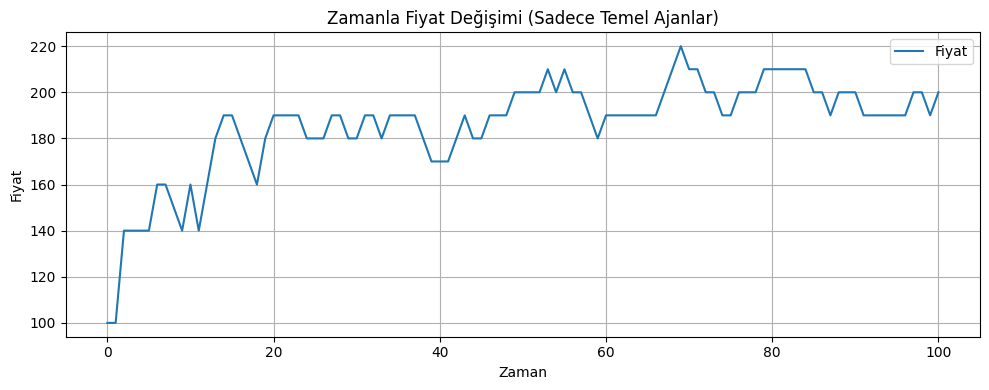

In [12]:

import matplotlib.pyplot as plt

# Sadece temel ajanlarla simülasyon
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Fiyatları çiz
price_history = model.price_history
plt.figure(figsize=(10, 4))
plt.plot(price_history, label="Fiyat")
plt.title("Zamanla Fiyat Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Görüntülenen çıkış son 5000 satıra kısaltıldı.
Step 167: New Price = 1
Step 167: Demand = 100, Supply = 200
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.04879999999999999
Step 168: New Price = 11.0
Step 168: Demand = 200, Supply = 100
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.13904000000000002
Step 169: New Price = 1
Step 169: Demand = 100, Supply = 200
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.24400000000000005
Step 170: New Price = 21.0
Step 170: Demand = 200, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_-0.19520000000000004
Step 171: New Price = 21.0
Step 171: Demand = 100, Supply = 100
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.25616000000000005
Step 172: New Price = 21.0
Step 172: Demand = 100, Supply = 100
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3

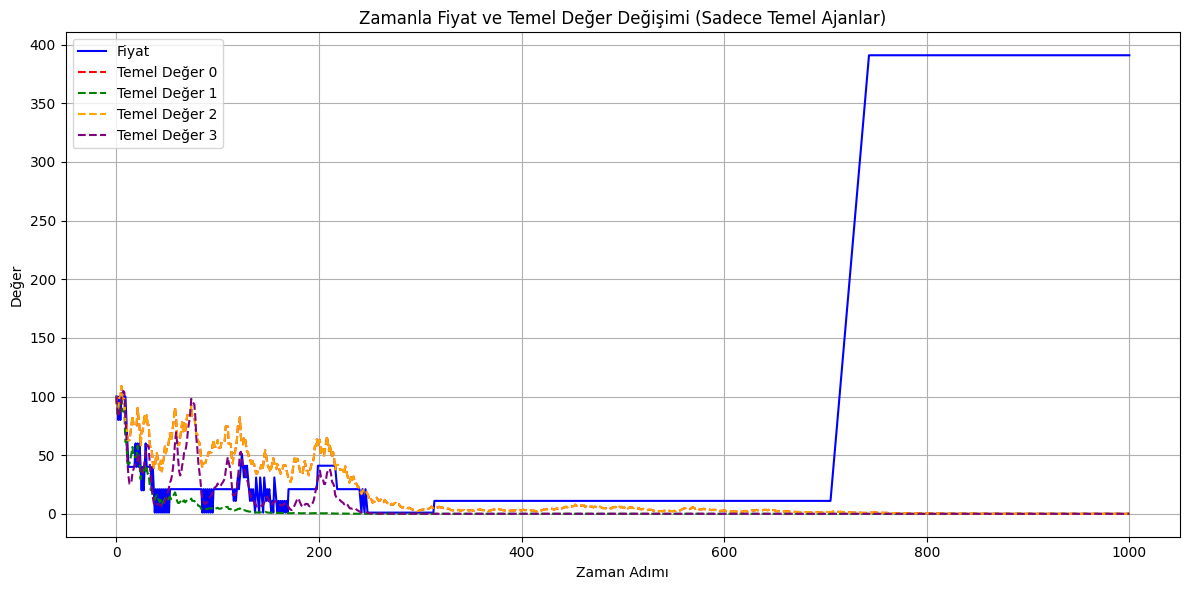

In [66]:

import matplotlib.pyplot as plt
# MarketModel sınıfınızın tanımlandığından emin olun (önceki hücreyi çalıştırarak)
# Agent ve strategy tanımlarının da yapıldığından emin olun

# Sadece temel ajanlarla simülasyon
# Daha önce düzeltilen MarketModel sınıfını kullanın
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=1000)

# Fiyatları ve Temel Değeri çiz
price_history = model.price_history
fundamental_history_0= model.fundamental_history_0 # Temel değer geçmişini al
fundamental_history_1= model.fundamental_history_1 # Temel değer geçmişini al
fundamental_history_2= model.fundamental_history_2 # Temel değer geçmişini al
fundamental_history_3= model.fundamental_history_3 # Temel değer geçmişini al




plt.figure(figsize=(12, 6)) # Grafik boyutunu büyütelim
plt.plot(price_history, label="Fiyat", color='blue')
plt.plot(fundamental_history_0, label="Temel Değer 0", color='red', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_1, label="Temel Değer 1", color='green', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_2, label="Temel Değer 2", color='orange', linestyle='--') # Temel değeri kesikli çizgiyle ekle
plt.plot(fundamental_history_3, label="Temel Değer 3", color='purple', linestyle='--') # Temel değeri kesikli çizgiyle ekle



plt.title("Zamanla Fiyat ve Temel Değer Değişimi (Sadece Temel Ajanlar)")
plt.xlabel("Zaman Adımı")
plt.ylabel("Değer")
plt.grid(True)
plt.legend()
plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()



In [115]:
import matplotlib.pyplot as plt
import pandas as pd
from mesa.datacollection import DataCollector
import random
import numpy as np # numpy'nin import edildiğinden emin ol

class MarketModel(mesa.Model):
    def __init__(self,
                 num_fundamental=400,
                 num_technical=400,
                 num_noise=400,
                 initial_price=100,
                 initial_fundamental_value=100):
        super().__init__()

        # Initialize total_demand and total_supply attributes
        self.total_demand = 0
        self.total_supply = 0


        self.price = initial_price
        self.prev_price = initial_price
        self.fundamental_value_0= initial_fundamental_value
        self.fundamental_value_1 = initial_fundamental_value
        self.fundamental_value_2 = initial_fundamental_value
        self.fundamental_value_3 = initial_fundamental_value


        self.prev_fundamental_value_0= initial_fundamental_value
        self.prev_fundamental_value_1 = initial_fundamental_value
        self.prev_fundamental_value_2 = initial_fundamental_value
        self.prev_fundamental_value_3 = initial_fundamental_value

        self.price_history = [initial_price]
        self.fundamental_history_0 = [initial_fundamental_value]
        self.fundamental_history_1 = [initial_fundamental_value]
        self.fundamental_history_2 = [initial_fundamental_value]
        self.fundamental_history_3 = [initial_fundamental_value]

        self.step_count = 0

        # self.news yerine news geçmişini tut
        self.news_history = []
        # Haber dağılımı
        self.news_values = [-2, -1, 0, 1, 2]
        self.news_probs = [0.05, 0.30, 0.30, 0.30, 0.05]

        # current_news değerini saklamak için bir attribute ekleyin
        self.current_news = 0
        self.cumulatif_news = 0





        # Ajanları oluştur
        # Fundamental agents
        for i in range(num_fundamental):
            strat_index = i % 4
            agent = FundamentalAgent(self, strat_index)
            self.agents.add(agent)

        # Technical agents
        for i in range(num_technical):
            strat_index = i % 4
            agent = TechnicalAgent(self, strat_index)
            self.agents.add(agent)

        # Noise agents
        for i in range(num_noise):
            strat_index = i % 4
            agent = NoiseAgent(self, strat_index)
            self.agents.add(agent)

        # DataCollector'ı tüm fundamental_value'ları içerecek şekilde güncelle
        self.datacollector = DataCollector(
            model_reporters={
                "Price": lambda m: m.price,
                "FundamentalValue_0": lambda m: m.fundamental_value_0,
                "FundamentalValue_1": lambda m: m.fundamental_value_1,
                "FundamentalValue_2": lambda m: m.fundamental_value_2,
                "FundamentalValue_3": lambda m: m.fundamental_value_3,
                "CurrentNews": lambda m: m.current_news, # current_news'u ekledik
                "CumulatifNews": lambda m: m.cumulatif_news # <-- Yeni: CumulatifNews'u ekledik
            }
        )

    def update_fundamental_value_0(self):
        # Sabit etki
        # news_history'deki son haberi kullan
        self.current_news = self.news_history[-1] if self.news_history else 0

        if self.current_news > 0:
            score_news_0 = self.current_news * 0.1 # pozitif haber
        elif self.current_news < 0:
            score_news_0 = self.current_news * 0.1 # negatif haber. pozitif haber ile aynı tepki
        else:
            score_news_0 = self.current_news # yeni haber yok

        #print(f"Haber/Bilgi_0: {score_news_0}")
        self.prev_fundamental_value_0= self.fundamental_value_0
        self.fundamental_value_0 += self.fundamental_value_0 * score_news_0
        print(f"fundamental_value_0: {self.fundamental_value_0}")
        self.fundamental_history_0.append(self.fundamental_value_0)


    def update_fundamental_value_1(self):
        # Asimetrik Etki veya aşırı tepki
        # news_history'deki son haberi kullan
        self.current_news = self.news_history[-1] if self.news_history else 0

        if self.current_news > 0:
            score_news_1 = self.current_news * 0.15 # pozitif haber
        elif self.current_news < 0:
            score_news_1 = self.current_news * 0.15 # negatif haber. pozitif haberden daha fazla duyarlılık
        else:
            score_news_1 = self.current_news # yeni haber yok

        #print(f"Haber/Bilgi_1: {score_news_1}")
        self.prev_fundamental_value_1 = self.fundamental_value_1
        self.fundamental_value_1 += self.fundamental_value_1 * score_news_1
        print(f"fundamental_value_1: {self.fundamental_value_1}")
        self.fundamental_history_1.append(self.fundamental_value_1)

    def update_fundamental_value_2(self):
        # Güçlenen Etki
        # news_history'deki son haberi kullan
        self.current_news = self.news_history[-1] if self.news_history else 0
        score_news_2 = 0
        score_news_2 = self.current_news * 0.1 + score_news_2 * 0.9


        #print(f"Haber/Bilgi_2: {score_news_2}")
        self.prev_fundamental_value_2 = self.fundamental_value_2
        self.fundamental_value_2 += self.fundamental_value_2 * score_news_2
        print(f"fundamental_value_2: {self.fundamental_value_2}")
        self.fundamental_history_2.append(self.fundamental_value_2)

    def update_fundamental_value_3(self):
        # Sönümlü Etki
        lam=0.4
        # News geçmişini kullan
        num_history_steps = 5
        # Yeterli geçmiş yoksa 0 kabul et
        recent_news = self.news_history[-min(len(self.news_history), num_history_steps):]

        score_news_3 = 0
        for i, news_val in enumerate(reversed(recent_news)):
             score_news_3 += news_val * (lam ** i)
        score_news_3 *= 0.1 # Ölçeklendirme faktörü

        #print(f"Haber/Bilgi_3: score_{score_news_3}")
        self.prev_fundamental_value_3 = self.fundamental_value_3
        self.fundamental_value_3 += self.fundamental_value_3 * score_news_3
        print(f"fundamental_value_3: {self.fundamental_value_3}")
        self.fundamental_history_3.append(self.fundamental_value_3)

    def update_price(self, demand, supply):
        #Fiyatı arz-talep farkına göre günceller.
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.1 * imbalance  # Duyarlılık katsayısı
        self.price = max(1, self.price)  # Negatif fiyatı engelle
        self.price_history.append(self.price)

    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1


        self.total_demand = 0
        self.total_supply = 0

        # Rastgele haberi oluştur ve geçmişe ekle
        self.current_news = np.random.choice(self.news_values, p=self.news_probs)
        self.news_history.append(self.current_news)
        self.cumulatif_news += self.current_news


        self.update_fundamental_value_0()
        self.update_fundamental_value_1()
        self.update_fundamental_value_2()
        self.update_fundamental_value_3()


        # Agent step method calls execute_action which updates model's total_demand/supply
        # agents.do() metodu çağrılırken, fundamental_strategies, technical_strategies, noise_strategies değişkenlerinin bu scope'ta erişilebilir olması gerekir.
        # __init__ metodunda agentları oluştururken bu strateji listelerine referans verilmişti.
        # Agent step metodları da bu global listeleri kullanıyor. Bu yapı çalışmalı.
        self.agents.do("step")

        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply)

        # Print price after update
        print(f"Step {self.step_count}: New Price = {self.price}")


        # Print demand and supply before price update
        print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")




        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for i in range(steps):
            print(f"----------Adım: {i}---------------")
            self.step()


Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.1
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.18000000000000002
Step 2: New Price = 80.0
Step 2: Demand = 100, Supply = 300
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_-0.14400000000000002
Step 3: New Price = 60.0
Step 3: Demand = 100, Supply = 300
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_-0.015200000000000026
Step 4: New Price = 80.0
Step 4: Demand = 300, Supply = 100
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.11216000000000002
Step 5: New Price = 60.0
Step 5: Demand = 100, Supply = 300
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.15696
Step 6: New Price = 60.0
Step 6: Demand = 200, Supply = 200
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/B

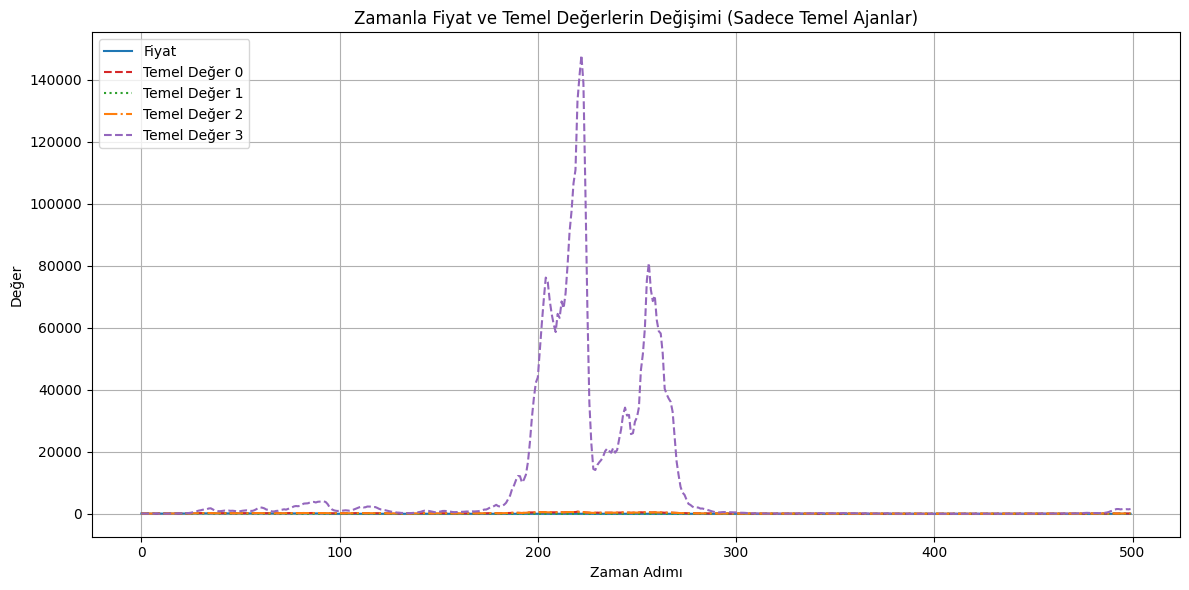

In [71]:

# Modeli çalıştır
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=500) # 1000 adım çalıştır

# Get the data from the DataCollector
results_df = model.datacollector.get_model_vars_dataframe()

# Grafik oluşturma (tek eksenli)
plt.figure(figsize=(12, 6))

# Fiyatı çiz
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')

# Temel değerleri aynı eksene çiz
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')

# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer')
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.1
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.18000000000000002
Step 2: New Price = 120.0
Step 2: Demand = 300, Supply = 100
-------------------------
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_0.04400000000000002
Step 3: New Price = 140.0
Step 3: Demand = 300, Supply = 100
-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.13520000000000004
Step 4: New Price = 120.0
Step 4: Demand = 100, Supply = 300
-------------------------
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_0.10816000000000002
Step 5: New Price = 120.0
Step 5: Demand = 200, Supply = 200
-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_

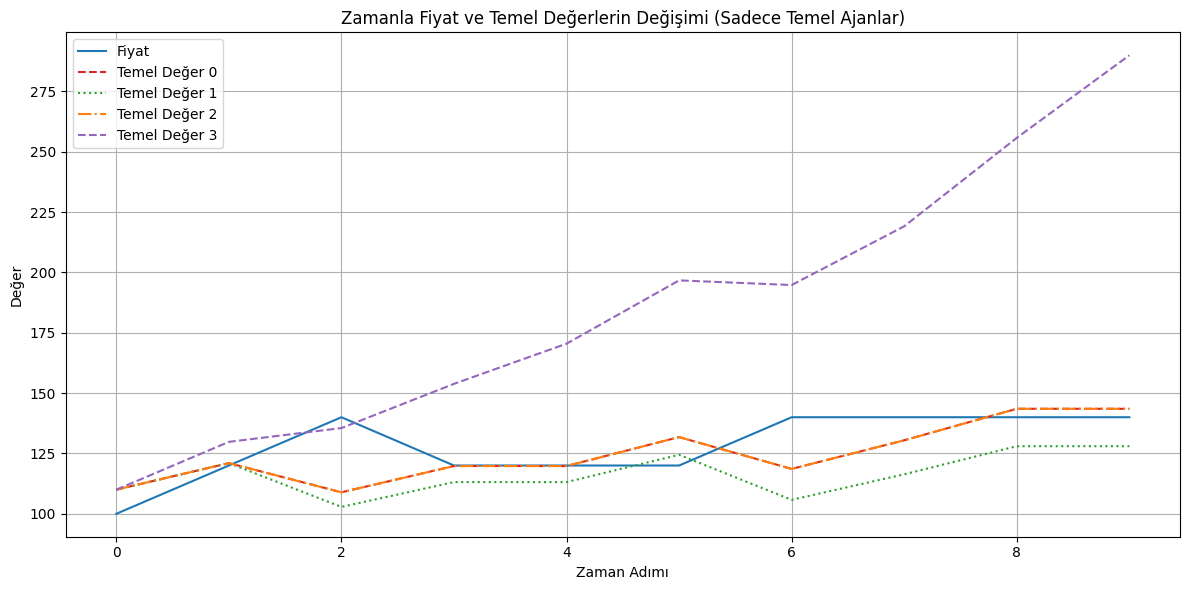

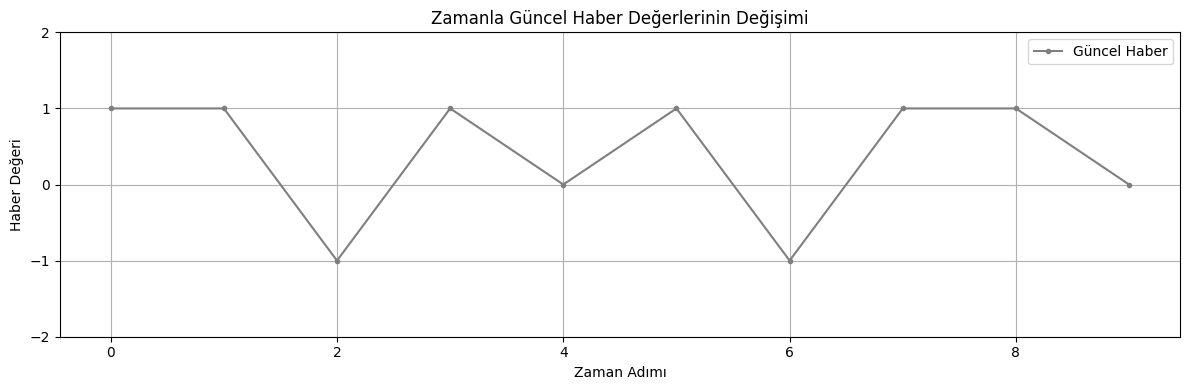

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # numpy import edildiğinden emin olun

# Modeli çalıştır
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=10)

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()

# === Fiyat ve Temel Değerler Grafiği ===
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla

# Fiyatı çiz
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')

# Temel değerleri aynı eksene çiz
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')

# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer') # Tek bir Y ekseni için genel başlık
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle
plt.legend(loc='upper left') # Tüm çizgiler için tek bir legend

plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

# === Haber Değerleri Grafiği (Ayrı Bir Grafik) ===
plt.figure(figsize=(12, 4)) # Haber için daha küçük bir grafik boyutu
plt.plot(results_df.index, results_df["CurrentNews"], label="Güncel Haber", color='tab:gray', linestyle='-', marker='.') # Haber değerlerini noktalarla göster
plt.xlabel('Zaman Adımı')
plt.ylabel('Haber Değeri')
plt.title('Zamanla Güncel Haber Değerlerinin Değişimi')
plt.grid(True)
# Y ekseni tiklerini belirlediğiniz değerlerle ayarla
plt.yticks([-2, -1, 0, 1, 2])
plt.legend()
plt.tight_layout()
plt.show()





-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.1
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
-------------------------
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.019999999999999997
Step 2: New Price = 120.0
Step 2: Demand = 300, Supply = 100
-------------------------
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_-0.015999999999999993
Step 3: New Price = 100.0
Step 3: Demand = 100, Supply = 300
-------------------------
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.0872
Step 4: New Price = 100.0
Step 4: Demand = 200, Supply = 200
-------------------------
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.030240000000000003
Step 5: New Price = 120.0
Step 5: Demand = 300, Supply = 100
-------------------------
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi

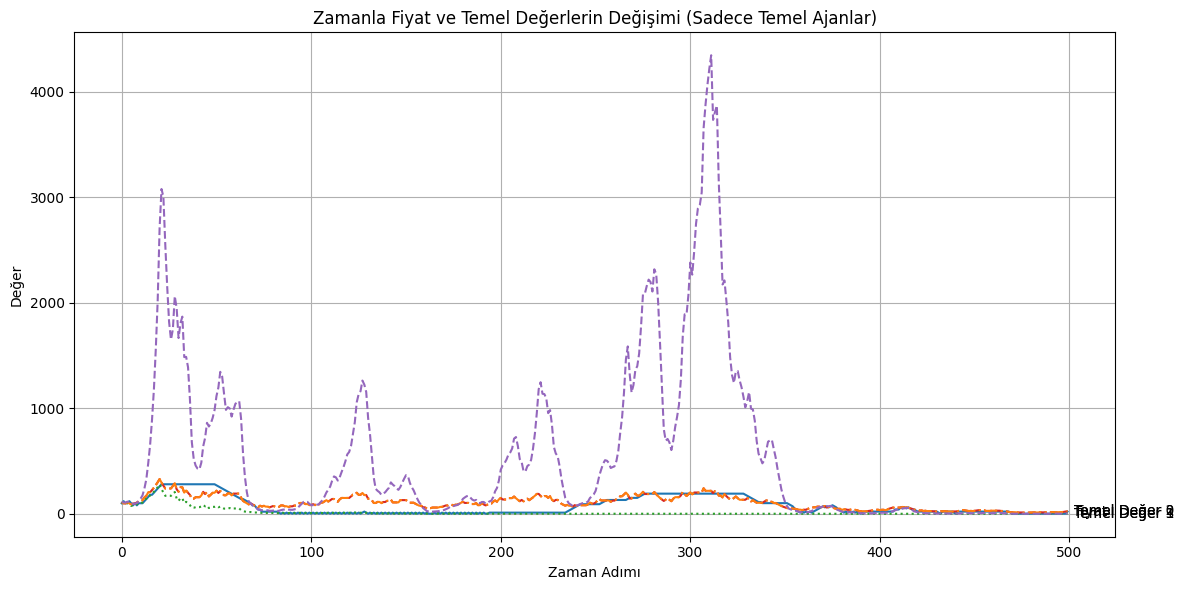

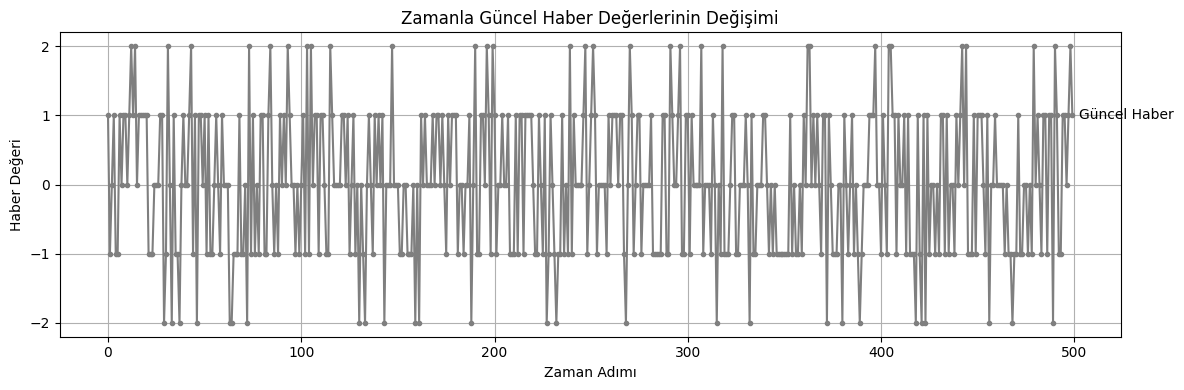

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Modeli çalıştır
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
# Daha anlamlı bir son nokta görmek için adım sayısını artırabiliriz.
# Ancak 10 adımda da son noktalar gösterilir.
model.run_model(steps=500)

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()

# === Fiyat ve Temel Değerler Grafiği ===
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla

# Çizilecek veriler ve etiket bilgileri (tuple listesi)
plot_data = [
    (results_df["Price"], "Fiyat", 'tab:blue', '-'),
    (results_df["FundamentalValue_0"], "Temel Değer 0", 'tab:red', '--'),
    (results_df["FundamentalValue_1"], "Temel Değer 1", 'tab:green', ':'),
    (results_df["FundamentalValue_2"], "Temel Değer 2", 'tab:orange', '-.'),
    (results_df["FundamentalValue_3"], "Temel Değer 3", 'tab:purple', '--')
]

# Her bir veriyi çiz ve son noktasına etiket ekle
for data, label, color, linestyle in plot_data:
    plt.plot(results_df.index, data, label=label, color=color, linestyle=linestyle)

    # Son veri noktasının koordinatları
    last_x = results_df.index[-1]
    last_y = data.iloc[-1]

    # Son noktaya etiket ekle
    plt.annotate(label,          # Etiket olarak çizginin ismini yaz
                 (last_x, last_y), # Etiketin yerleştirileceği nokta (son nokta)
                 textcoords="offset points", # Metnin noktanın neresine göre konumlanacağı
                 xytext=(5, 0),    # Noktadan ne kadar kaydırılacağı (sağa 5 piksel)
                 ha='left',        # Metnin yatay hizalaması (noktanın soluna göre hizala)
                 va='center')      # Metnin dikey hizalaması (noktanın ortasına göre hizala)


# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer') # Tek bir Y ekseni için genel başlık
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle (isteğe bağlı, artık etiketler doğrudan grafikte)
# plt.legend(loc='upper left')

plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

# === Haber Değerleri Grafiği (Ayrı Bir Grafik - Son Etiketle) ===
plt.figure(figsize=(12, 4)) # Haber için daha küçük bir grafik boyutu

# Haber değerlerini çiz
plt.plot(results_df.index, results_df["CurrentNews"],
         label="Güncel Haber",
         color='tab:gray',
         linestyle='-',
         marker='.')

# Son veri noktasının koordinatları
last_x = results_df.index[-1]
last_y = results_df["CurrentNews"].iloc[-1]

# Son noktaya etiket ekle
plt.annotate("Güncel Haber", # Etiket olarak çizginin ismini yaz
             (last_x, last_y), # Etiketin yerleştirileceği nokta (son nokta)
             textcoords="offset points", # Metnin noktanın neresine göre konumlanacağı
             xytext=(5, 0),    # Noktadan ne kadar kaydırılacağı (sağa 5 piksel)
             ha='left',        # Metnin yatay hizalaması (noktanın soluna göre hizala)
             va='center')      # Metnin dikey hizalaması (noktanın ortasına göre hizala)


plt.xlabel('Zaman Adımı')
plt.ylabel('Haber Değeri')
plt.title('Zamanla Güncel Haber Değerlerinin Değişimi')
plt.grid(True)
# Y ekseni tiklerini belirlediğiniz değerlerle ayarla
plt.yticks([-2, -1, 0, 1, 2])
# Legend ekle (isteğe bağlı)
# plt.legend()
plt.tight_layout()
plt.show()

----------Adım: 0---------------
fundamental_value_0: 90.0
fundamental_value_1: 85.0
fundamental_value_2: 90.0
fundamental_value_3: 90.0
Step 1: New Price = 60.0
Step 1: Demand = 0, Supply = 400
----------Adım: 1---------------
fundamental_value_0: 81.0
fundamental_value_1: 72.25
fundamental_value_2: 81.0
fundamental_value_3: 77.4
Step 2: New Price = 100.0
Step 2: Demand = 400, Supply = 0
----------Adım: 2---------------
fundamental_value_0: 89.1
fundamental_value_1: 83.0875
fundamental_value_2: 89.1
fundamental_value_3: 80.80560000000001
Step 3: New Price = 60.0
Step 3: Demand = 0, Supply = 400
----------Adım: 3---------------
fundamental_value_0: 98.00999999999999
fundamental_value_1: 95.55062500000001
fundamental_value_2: 98.00999999999999
fundamental_value_3: 90.30833856000001
Step 4: New Price = 100.0
Step 4: Demand = 400, Supply = 0
----------Adım: 4---------------
fundamental_value_0: 88.20899999999999
fundamental_value_1: 81.21803125000001
fundamental_value_2: 88.20899999999999

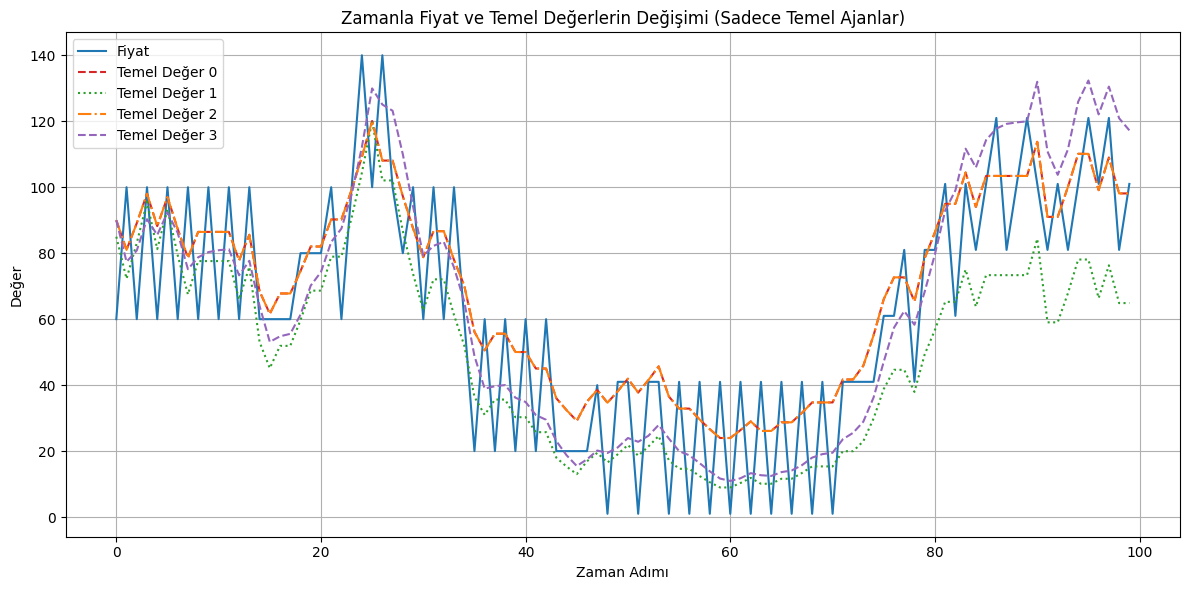

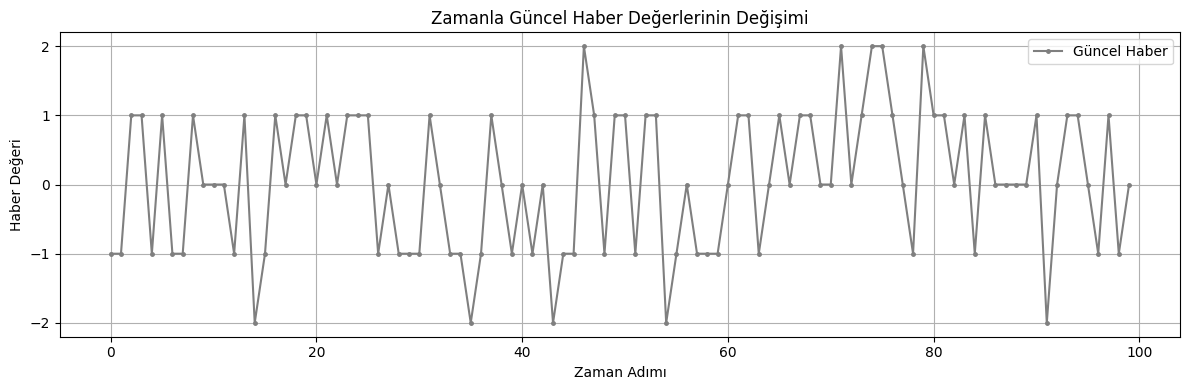

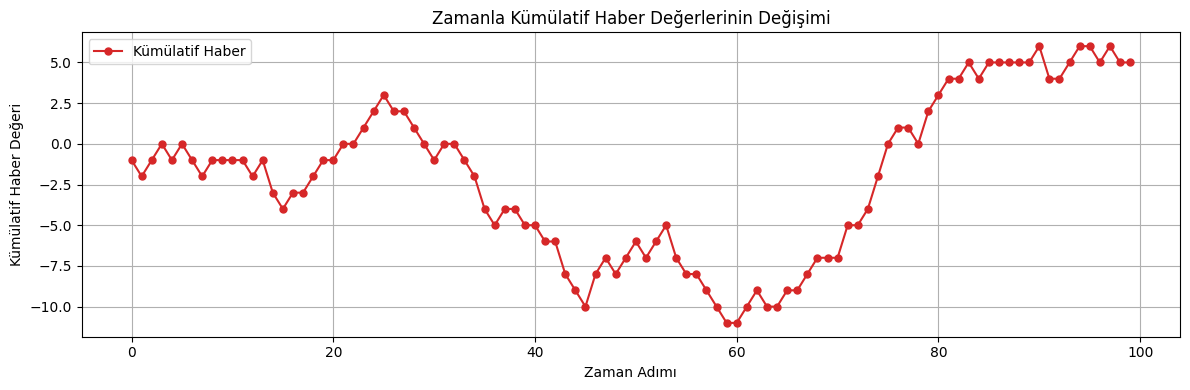

In [123]:

# Modeli çalıştır
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100) # 100 adım çalıştır

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()


# === Fiyat ve Temel Değerler Grafiği ===
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla

# Fiyatı çiz
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')

# Temel değerleri aynı eksene çiz
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')

# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer') # Tek bir Y ekseni için genel başlık
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle
plt.legend(loc='upper left') # Tüm çizgiler için tek bir legend

plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

# === Haber Değerleri Grafiği (Ayrı Bir Grafik) ===
plt.figure(figsize=(12, 4)) # Haber için daha küçük bir grafik boyutu

# CurrentNews'u çiz
plt.plot(results_df.index, results_df["CurrentNews"],
         label="Güncel Haber",
         color='tab:gray',
         linestyle='-',
         marker='.',
         markersize=5) # Marker boyutunu artır

plt.xlabel('Zaman Adımı')
plt.ylabel('Haber Değeri')
plt.title('Zamanla Güncel Haber Değerlerinin Değişimi')
plt.grid(True)
# Y ekseni tiklerini belirlediğiniz değerlerle ayarla
plt.yticks([-2, -1, 0, 1, 2])
plt.legend()
plt.tight_layout()
plt.show()

# === Kümülatif Haber Grafiği (Yeni Grafik) ===
plt.figure(figsize=(12, 4)) # Grafik boyutu

# CumulatifNews'u çiz
plt.plot(results_df.index, results_df["CumulatifNews"],
         label="Kümülatif Haber",
         color='tab:red', # Farklı bir renk
         linestyle='-',
         marker='o',      # Farklı bir marker
         markersize=5)

plt.xlabel('Zaman Adımı')
plt.ylabel('Kümülatif Haber Değeri')
plt.title('Zamanla Kümülatif Haber Değerlerinin Değişimi')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.1
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.18000000000000002
Step 2: New Price = 80.0
Step 2: Demand = 100, Supply = 300
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.24400000000000005
Step 3: New Price = 60.0
Step 3: Demand = 100, Supply = 300
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.2952000000000001
Step 4: New Price = 60.0
Step 4: Demand = 200, Supply = 200
Haber/Bilgi_0: 0.2
Haber/Bilgi_1: 0.2
Haber/Bilgi_2: 0.2
Haber/Bilgi_3: score_-0.03616000000000004
Step 5: New Price = 40.0
Step 5: Demand = 100, Supply = 300
0    90.000000
1    73.800000
2    55.792800
3    39.322765
4    37.900854
Name: FundamentalValue_3, dtype: float64


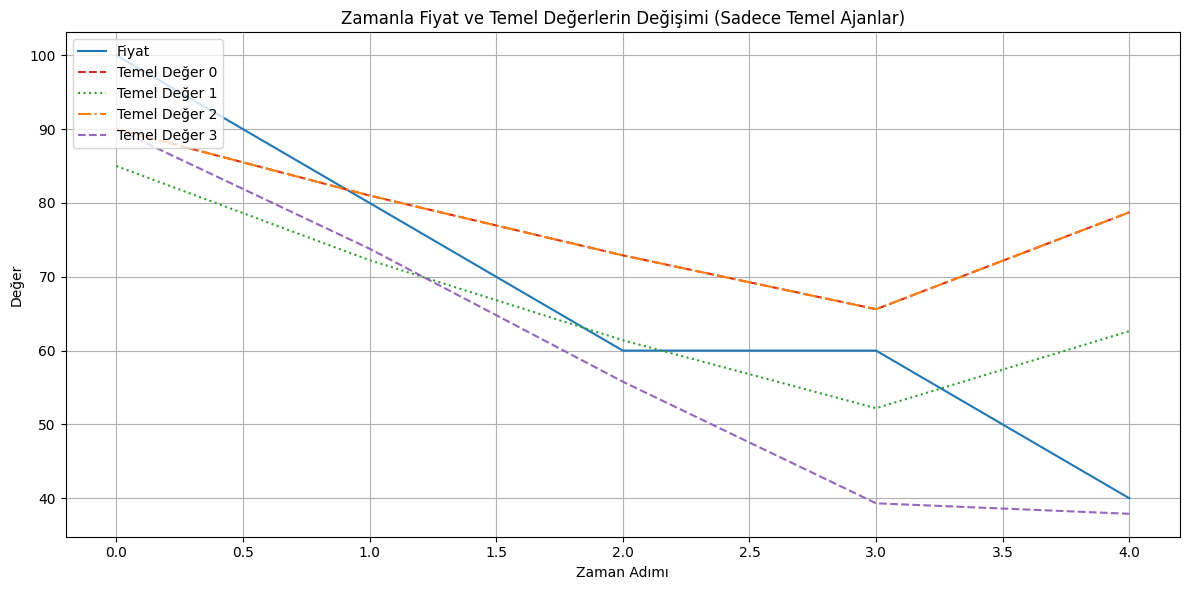

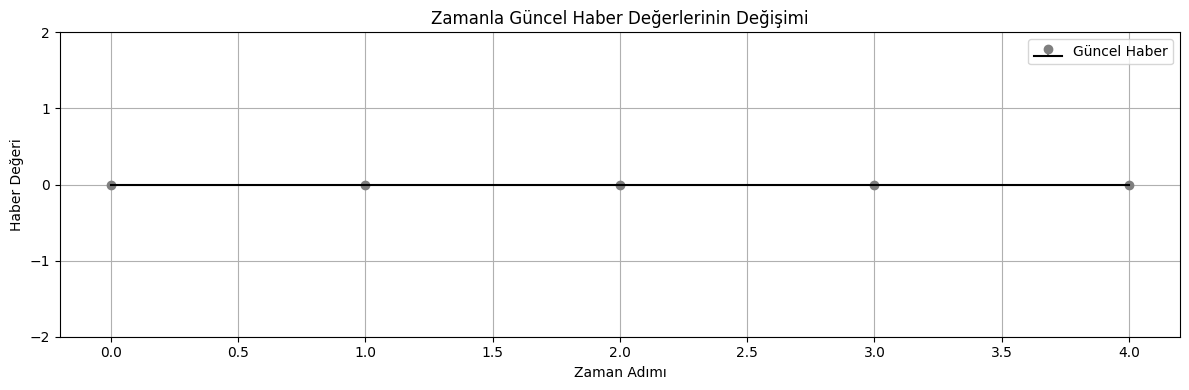

[np.int64(-1), np.int64(-1), np.int64(-1), np.int64(-1), np.int64(2)]

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # numpy import edildiğinden emin olun

# Model çalıştırma ve data alma kısmı aynı kalacak
# Modeli çalıştırırken adım sayısını artırabilirsiniz
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=5) # Adım sayısını 500'e çıkardık

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()
print(results_df["FundamentalValue_3"])
# === Fiyat ve Temel Değerler Grafiği ===
# Bu kısım aynı kalacak
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer')
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# === Haber Değerleri Grafiği (Ayrı Bir Grafik - Geliştirilmiş Görünürlük) ===
plt.figure(figsize=(12, 4)) # Haber için daha küçük bir grafik boyutu

# Option 1: Geliştirilmiş plot ile çizgi ve marker
# plt.plot(results_df.index, results_df["CurrentNews"], label="Güncel Haber", color='tab:gray', linestyle='-', marker='.', markersize=8, linewidth=2) # Marker boyutunu ve çizgi kalınlığını artır

# Option 2: Sadece markerları göster (çizgisiz)
# plt.plot(results_df.index, results_df["CurrentNews"], label="Güncel Haber", color='tab:gray', linestyle='None', marker='o', markersize=5) # Çizgisiz, yuvarlak markerlar

# Option 3: Stemma grafik (Kesikli değerler için daha uygun olabilir)
plt.stem(results_df.index, results_df["CurrentNews"], linefmt='C7-', markerfmt='C7o', basefmt='k-', label="Güncel Haber") # Gri renkte gövdeli grafik

plt.xlabel('Zaman Adımı')
plt.ylabel('Haber Değeri')
plt.title('Zamanla Güncel Haber Değerlerinin Değişimi')
plt.grid(True)
# Y ekseni tiklerini belirlediğiniz değerlerle ayarla
plt.yticks([-2, -1, 0, 1, 2])
plt.legend()
plt.tight_layout()
plt.show()

model.news_history

Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_0.0
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.1
Step 2: New Price = 100.0
Step 2: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_-0.08000000000000002
Step 3: New Price = 80.0
Step 3: Demand = 100, Supply = 300
Haber/Bilgi_0: 0.1
Haber/Bilgi_1: 0.1
Haber/Bilgi_2: 0.1
Haber/Bilgi_3: score_0.03599999999999999
Step 4: New Price = 100.0
Step 4: Demand = 300, Supply = 100
Haber/Bilgi_0: -0.1
Haber/Bilgi_1: -0.15
Haber/Bilgi_2: -0.1
Haber/Bilgi_3: score_-0.07120000000000001
Step 5: New Price = 80.0
Step 5: Demand = 100, Supply = 300
Haber/Bilgi_0: 0.2
Haber/Bilgi_1: 0.2
Haber/Bilgi_2: 0.2
Haber/Bilgi_3: score_0.14304000000000003
Step 6: New Price = 60.0
Step 6: Demand = 100, Supply = 300
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Haber/Bilgi_3: score_0.1472
Step 

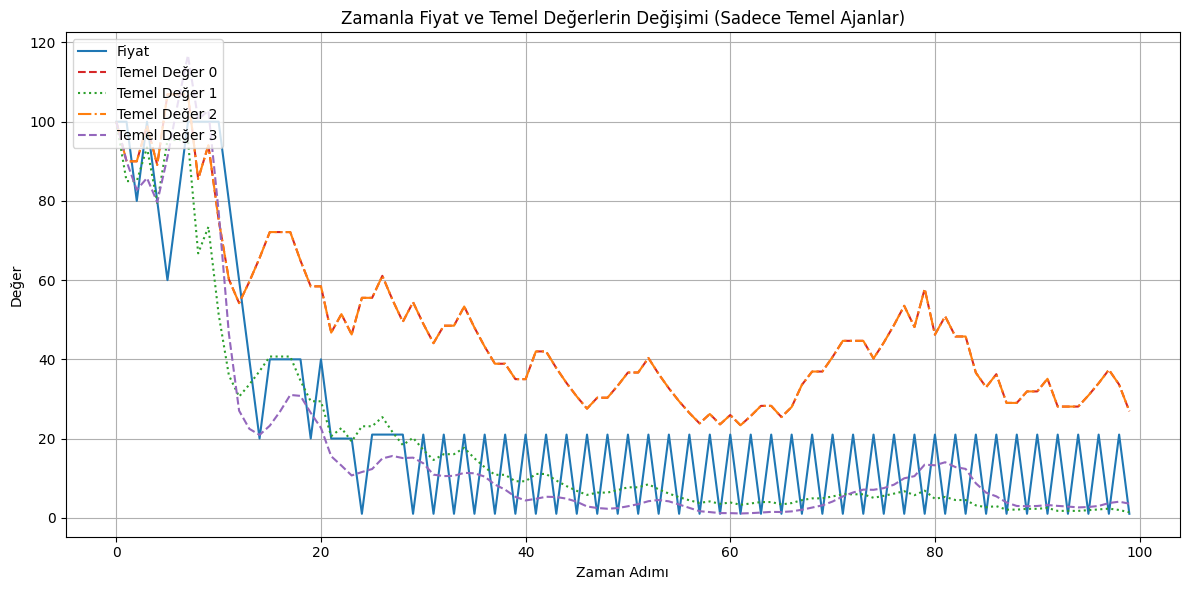

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# MarketModel sınıfınızın ve ajan/strateji tanımlarınızın çalıştığından emin olun.
# DataCollector'ın tüm fundamental_value'ları topladığından emin olun.

# Modeli çalıştır
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()

# Grafik oluşturma (tek eksenli)
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla

# Fiyatı çiz
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')

# Temel değerleri aynı eksene çiz
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')

# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer') # Tek bir Y ekseni için genel başlık
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle
plt.legend(loc='upper left') # Tüm çizgiler için tek bir legend

plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 1: New Price = 100.0
Step 1: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 2: New Price = 100.0
Step 2: Demand = 0, Supply = 0
Haber/Bilgi_0: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Step 3: New Price = 100.0
Step 3: Demand = 0, Supply = 0
Haber/Bilgi_0: -0.0
Haber/Bilgi_1: -0.0
Haber/Bilgi_2: 0.0
Step 4: New Price = 100.0
Step 4: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 5: New Price = 100.0
Step 5: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 6: New Price = 100.0
Step 6: Demand = 0, Supply = 0
Haber/Bilgi_0: 0.0
Haber/Bilgi_1: 0.0
Haber/Bilgi_2: 0.0
Step 7: New Price = 100.0
Step 7: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 8: New Price = 100.0
Step 8: Demand = 0, Supply = 0
Haber/Bilgi_0: 0
Haber/Bilgi_1: 0
Haber/Bilgi_2: 0.0
Step 9: New Price = 100.0
Step 9: Demand = 0, Supply 

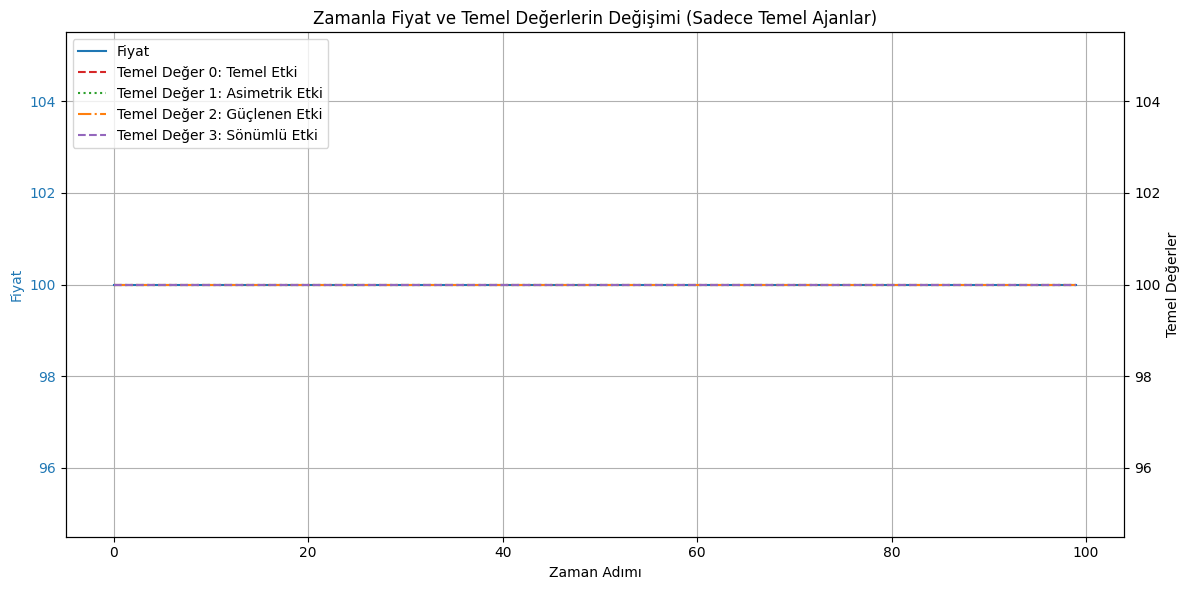

In [24]:
import matplotlib.pyplot as plt
import pandas as pd # pandas'ı import ettiğinizden emin olun

# MarketModel sınıfınızın tanımlandığından emin olun (önceki hücreyi çalıştırarak)
# Agent ve strategy tanımlarının da yapıldığından emin olun

# Sadece temel ajanlarla simülasyon
# Daha önce düzeltilen MarketModel sınıfını kullanın
model = MarketModel(num_fundamental=400, num_technical=0, num_noise=0)
model.run_model(steps=100)

# Get the data from the DataCollector
# DataCollector artık tüm fundamental_value'ları ilgili sütunlarda topluyor
results_df = model.datacollector.get_model_vars_dataframe()

# Fiyatları ve Temel Değerleri çiz

fig, ax1 = plt.subplots(figsize=(12, 6)) # Grafik boyutunu büyütelim ve ilk ekseni oluştur

# Birincil Y ekseni (Sol): Fiyat
color = 'tab:blue'
ax1.set_xlabel('Zaman Adımı')
ax1.set_ylabel('Fiyat', color=color)
ax1.plot(results_df.index, results_df["Price"], label="Fiyat", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# İkincil Y ekseni (Sağ): Temel Değerler
ax2 = ax1.twinx() # x eksenini paylaşan ikinci ekseni oluştur
ax2.set_ylabel('Temel Değerler') # Ortak bir başlık kullanalım

# Farklı temel değerleri farklı renklerle çiz
ax2.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0: Temel Etki", color='tab:red', linestyle='--')
ax2.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1: Asimetrik Etki", color='tab:green', linestyle=':') # Farklı linestyle
ax2.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2: Güçlenen Etki", color='tab:orange', linestyle='-.') # Farklı linestyle
ax2.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3: Sönümlü Etki", color='tab:purple', linestyle='--') # Farklı renk ve linestyle

ax2.tick_params(axis='y') # İkincil eksen için tick ayarlamaları

# Grafik başlığı
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Legend'ları birleştirme
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left') # Legend'ı sol üste koy

fig.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()